# ML Model Comparison for Hospital Symptoms Dataset

This notebook trains several classification models on the hospital symptoms dataset and compares their performance using accuracy, weighted F1 score, and confusion matrices.

> Note: This file is standalone and only demonstrates results. It does not modify existing project structure or application logic.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', palette='muted', font_scale=1.1)

In [3]:
DATA_PATH = Path('ml_model') / 'dataset' / 'symptoms_dataset.csv'
df = pd.read_csv(DATA_PATH)

print('Dataset path:', DATA_PATH.resolve())
print('Shape:', df.shape)
display(df.head())
print('\nClass distribution:')
print(df['disease'].value_counts())

Dataset path: C:\Users\chand\OneDrive\Desktop\Hospital\ml_model\dataset\symptoms_dataset.csv
Shape: (5000, 11)


,fever,cough,headache,fatigue,nausea,vomiting,chest_pain,shortness_of_breath,dizziness,sore_throat,disease
0,1,1,1,0,0,0,1,0,1,1,Flu
1,1,0,1,1,0,0,1,0,1,1,Heart Disease
2,0,0,1,0,0,1,1,0,0,1,Healthy
3,0,1,0,0,1,0,1,1,1,1,Cold
4,0,1,0,1,1,0,0,0,0,0,Healthy



Class distribution:
disease
Healthy           1012
Heart Disease      959
Food Poisoning     722
Flu                632
Cold               630
Anemia             366
Viral Fever        342
Asthma             337
Name: count, dtype: int64


In [4]:
X = df.drop(columns=['disease'])
y = df['disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (4000, 10)
Test shape: (1000, 10)


In [8]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(probability=True, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({
        'model': name,
        'accuracy': acc,
        'weighted_f1': f1
    })
    trained_models[name] = model
    print(f'--- {name} ---')
    print('Accuracy:', round(acc, 4))
    print('Weighted F1:', round(f1, 4))
    print(classification_report(y_test, y_pred, zero_division=0))
    print()

results_df = pd.DataFrame(results).sort_values(by='accuracy', ascending=False).reset_index(drop=True)
display(results_df)

--- Decision Tree ---
Accuracy: 1.0
Weighted F1: 1.0
                precision    recall  f1-score   support

        Anemia       1.00      1.00      1.00        73
        Asthma       1.00      1.00      1.00        68
          Cold       1.00      1.00      1.00       126
           Flu       1.00      1.00      1.00       126
Food Poisoning       1.00      1.00      1.00       144
       Healthy       1.00      1.00      1.00       203
 Heart Disease       1.00      1.00      1.00       192
   Viral Fever       1.00      1.00      1.00        68

      accuracy                           1.00      1000
     macro avg       1.00      1.00      1.00      1000
  weighted avg       1.00      1.00      1.00      1000


--- Random Forest ---
Accuracy: 1.0
Weighted F1: 1.0
                precision    recall  f1-score   support

        Anemia       1.00      1.00      1.00        73
        Asthma       1.00      1.00      1.00        68
          Cold       1.00      1.00      1.00    

,model,accuracy,weighted_f1
0,Decision Tree,1.000,1.000000
1,Random Forest,1.000,1.000000
2,Gradient Boosting,1.000,1.000000
3,Logistic Regression,1.000,1.000000
4,Support Vector Machine,1.000,1.000000
5,K-Nearest Neighbors,0.977,0.976872


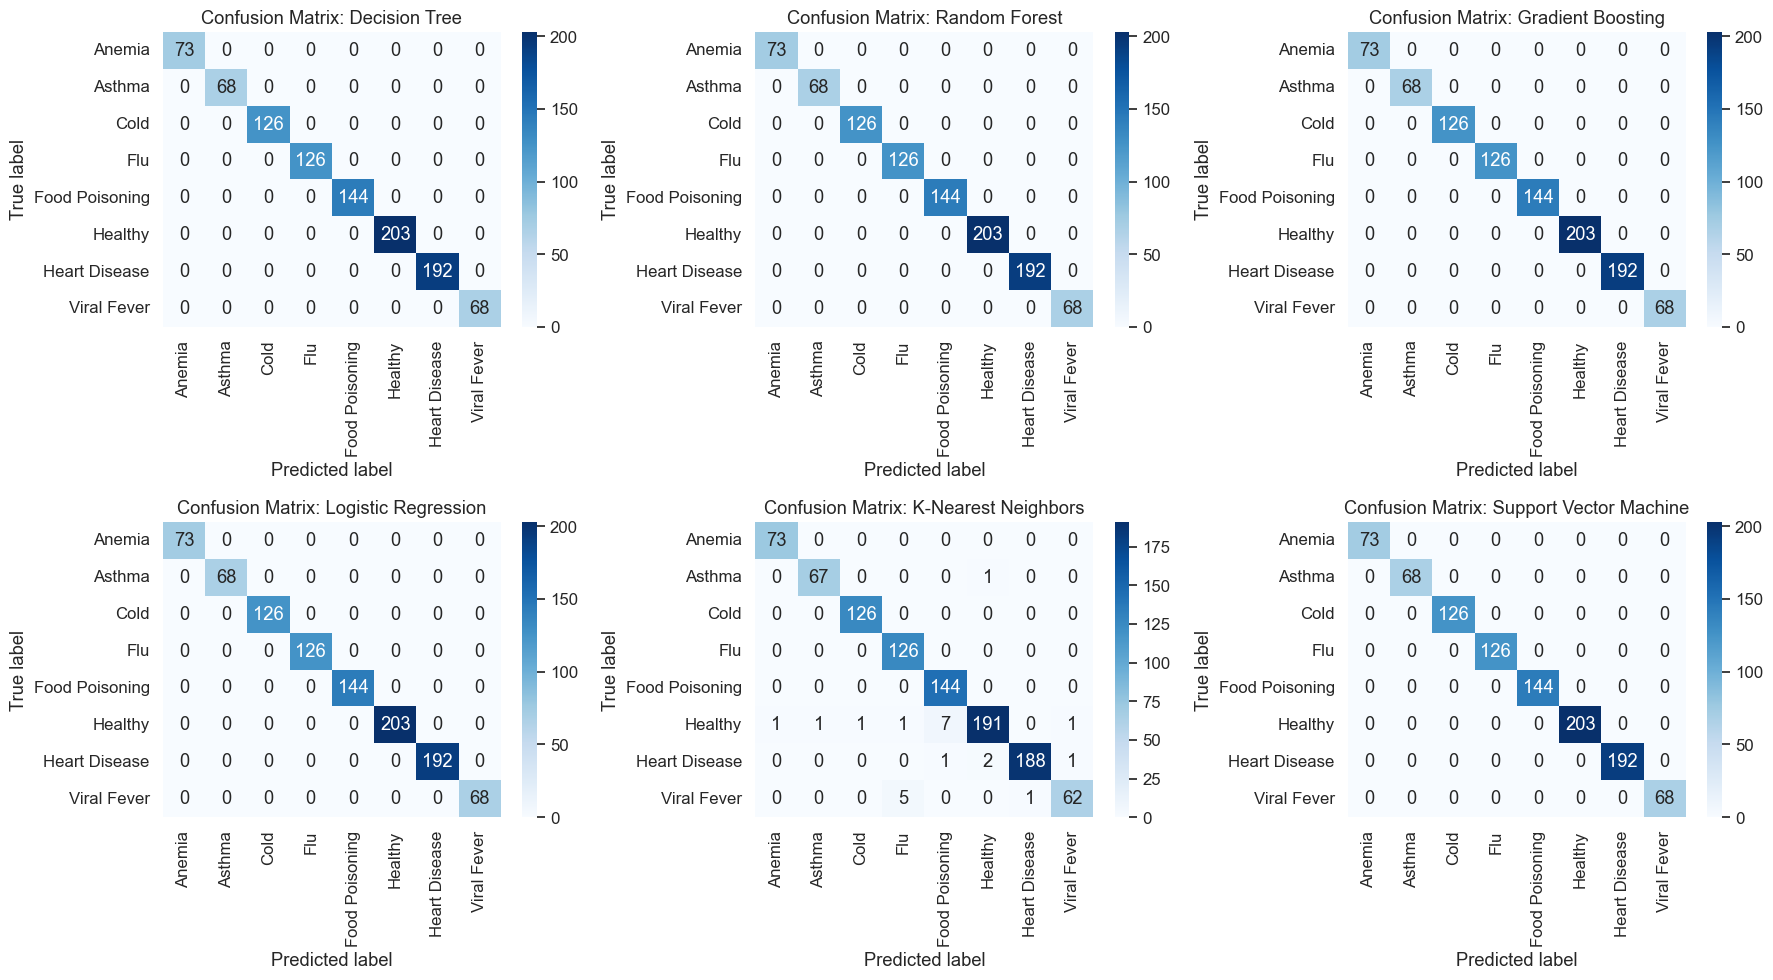

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=model.classes_, yticklabels=model.classes_)
    axes[idx].set_title(f'Confusion Matrix: {name}')
    axes[idx].set_ylabel('True label')
    axes[idx].set_xlabel('Predicted label')

for j in range(len(trained_models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

C:\Users\chand\AppData\Local\Temp\ipykernel_19304\2377580194.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='accuracy', y='model', palette='viridis', ax=ax)


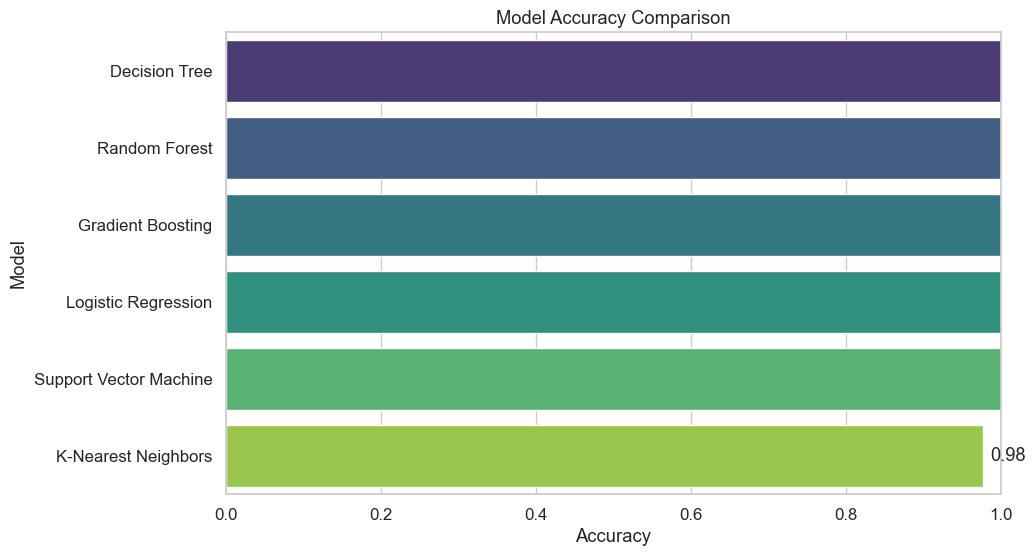

C:\Users\chand\AppData\Local\Temp\ipykernel_19304\2377580194.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='weighted_f1', y='model', palette='magma', ax=ax)


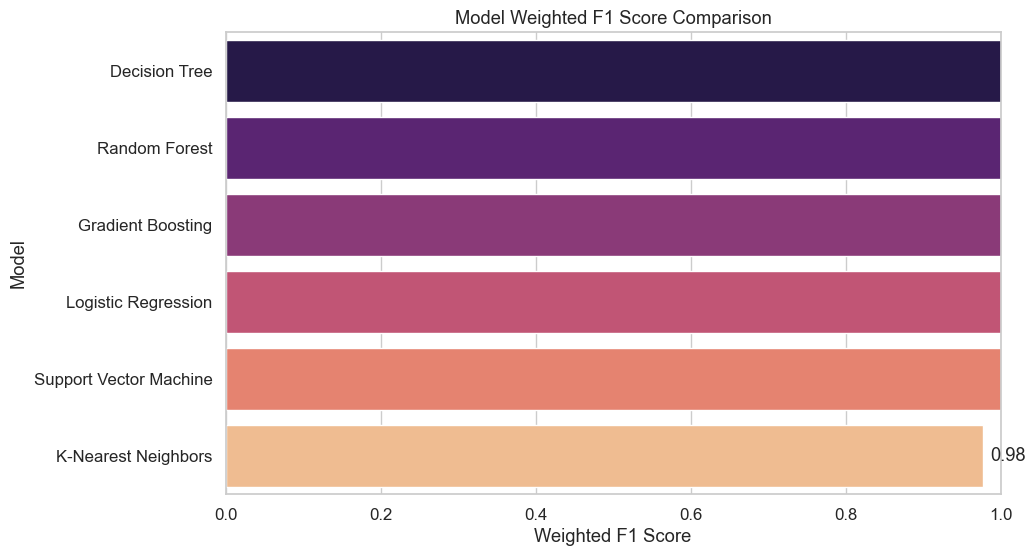

In [7]:
comparison_df = results_df.copy()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=comparison_df, x='accuracy', y='model', palette='viridis', ax=ax)
ax.set_title('Model Accuracy Comparison')
ax.set_xlabel('Accuracy')
ax.set_ylabel('Model')
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}', (p.get_width() + 0.01, p.get_y() + p.get_height() / 2),
                va='center')
plt.xlim(0, 1)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=comparison_df, x='weighted_f1', y='model', palette='magma', ax=ax)
ax.set_title('Model Weighted F1 Score Comparison')
ax.set_xlabel('Weighted F1 Score')
ax.set_ylabel('Model')
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}', (p.get_width() + 0.01, p.get_y() + p.get_height() / 2),
                va='center')
plt.xlim(0, 1)
plt.show()

# Detailed Analysis: Decision Tree Classifier

This section provides an in-depth look at the Decision Tree model used in the hospital system, including its structure, performance metrics, and interpretability features.

In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train Decision Tree with specific parameters
dt_model = DecisionTreeClassifier(
    max_depth=5,  # Limit depth for better visualization
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

# Predictions
dt_y_pred = dt_model.predict(X_test)
dt_y_pred_proba = dt_model.predict_proba(X_test)

# Performance metrics
dt_accuracy = accuracy_score(y_test, dt_y_pred)
dt_f1 = f1_score(y_test, dt_y_pred, average='weighted')

print("=== Decision Tree Performance ===")
print(f"Accuracy: {dt_accuracy:.4f}")
print(f"Weighted F1 Score: {dt_f1:.4f}")
print(f"Tree Depth: {dt_model.get_depth()}")
print(f"Number of Leaves: {dt_model.get_n_leaves()}")
print(f"Number of Features: {dt_model.n_features_in_}")

print("\nClassification Report:")
print(classification_report(y_test, dt_y_pred, zero_division=0))

=== Decision Tree Performance ===
Accuracy: 0.7940
Weighted F1 Score: 0.7896
Tree Depth: 5
Number of Leaves: 27
Number of Features: 10

Classification Report:
                precision    recall  f1-score   support

        Anemia       0.41      0.33      0.37        73
        Asthma       0.92      0.79      0.85        68
          Cold       0.86      1.00      0.92       126
           Flu       1.00      0.75      0.85       126
Food Poisoning       0.66      0.55      0.60       144
       Healthy       0.70      0.80      0.75       203
 Heart Disease       1.00      1.00      1.00       192
   Viral Fever       0.64      0.91      0.75        68

      accuracy                           0.79      1000
     macro avg       0.77      0.77      0.76      1000
  weighted avg       0.80      0.79      0.79      1000



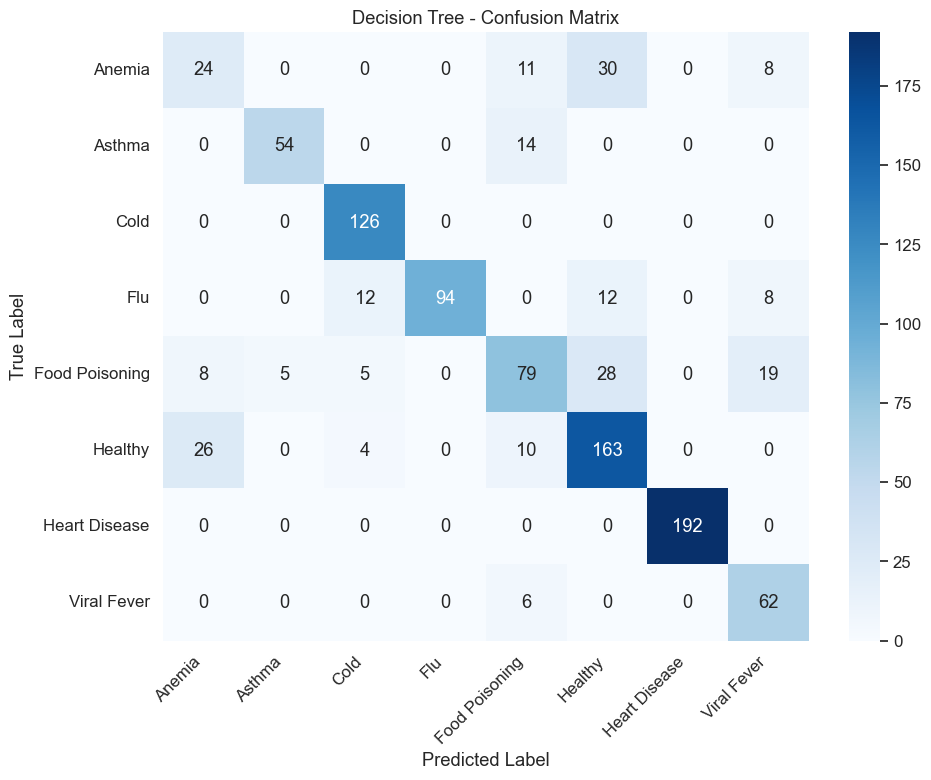

In [10]:
# Confusion Matrix for Decision Tree
dt_cm = confusion_matrix(y_test, dt_y_pred, labels=dt_model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dt_model.classes_,
            yticklabels=dt_model.classes_)
plt.title('Decision Tree - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\chand\AppData\Local\Temp\ipykernel_19304\1305469010.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')


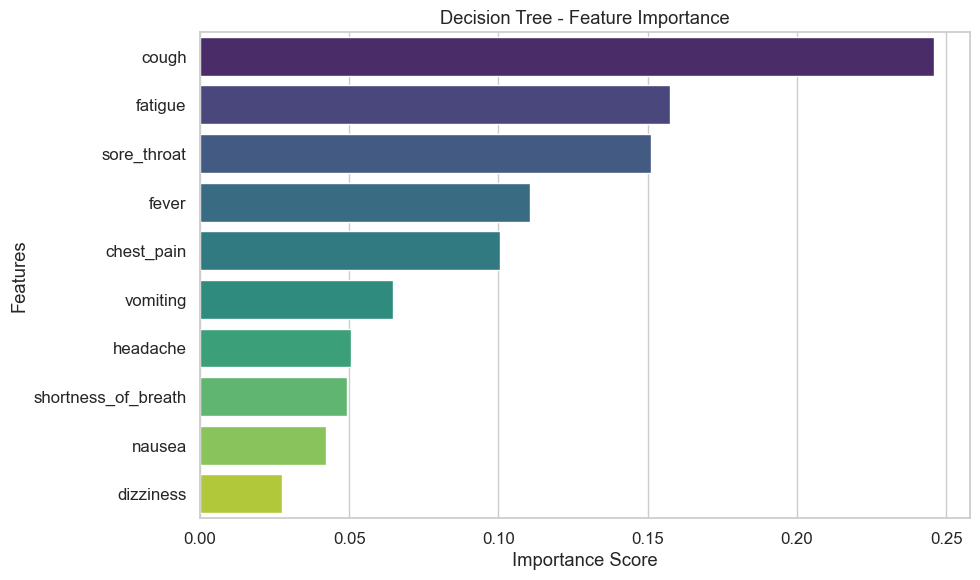

Top 5 Most Important Features:


,feature,importance
1,cough,0.245826
3,fatigue,0.157536
9,sore_throat,0.151250
0,fever,0.110482
6,chest_pain,0.100610


In [11]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Decision Tree - Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features:")
display(feature_importance.head())

,Class,Precision,Recall,F1-Score,Support
0,Anemia,0.4138,0.3288,0.3664,73
1,Asthma,0.9153,0.7941,0.8504,68
2,Cold,0.8571,1.0000,0.9231,126
3,Flu,1.0000,0.7460,0.8545,126
4,Food Poisoning,0.6583,0.5486,0.5985,144
5,Healthy,0.6996,0.8030,0.7477,203
6,Heart Disease,1.0000,1.0000,1.0000,192
7,Viral Fever,0.6392,0.9118,0.7515,68


C:\Users\chand\AppData\Local\Temp\ipykernel_19304\3228170063.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_metrics, x='Class', y='Precision', ax=axes[0], palette='Blues')
C:\Users\chand\AppData\Local\Temp\ipykernel_19304\3228170063.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\chand\AppData\Local\Temp\ipykernel_19304\3228170063.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_metrics, x='Class', y='Recall', ax=axes[1], palette='Greens')
C:\Users\chand\AppData\Local\Temp\ipykernel_1930

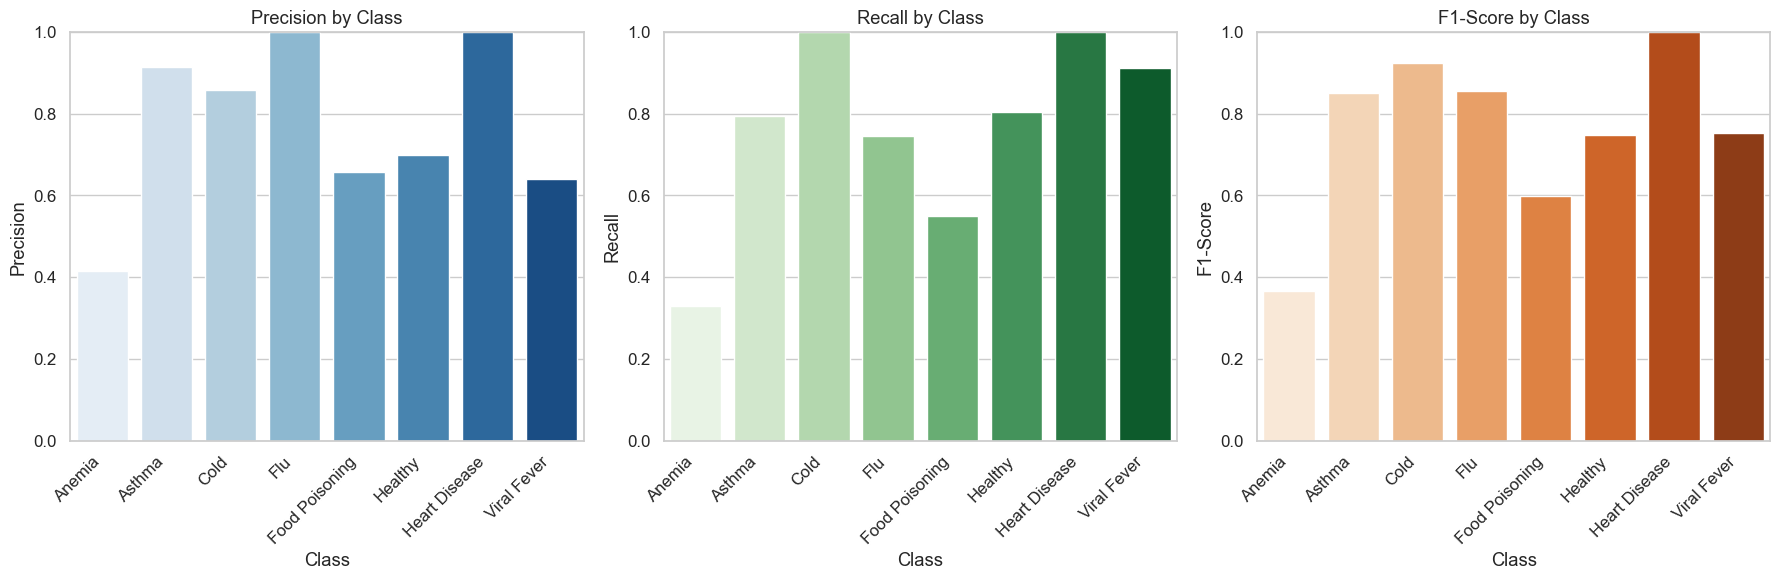

In [14]:
# Per-Class Performance Analysis
from sklearn.metrics import precision_recall_fscore_support

precision, recall, fscore, support = precision_recall_fscore_support(y_test, dt_y_pred, average=None, labels=dt_model.classes_)

class_metrics = pd.DataFrame({
    'Class': dt_model.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': fscore,
    'Support': support
}).round(4)

display(class_metrics)

# Plot per-class metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Precision
sns.barplot(data=class_metrics, x='Class', y='Precision', ax=axes[0], palette='Blues')
axes[0].set_title('Precision by Class')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylim(0, 1)

# Recall
sns.barplot(data=class_metrics, x='Class', y='Recall', ax=axes[1], palette='Greens')
axes[1].set_title('Recall by Class')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylim(0, 1)

# F1-Score
sns.barplot(data=class_metrics, x='Class', y='F1-Score', ax=axes[2], palette='Oranges')
axes[2].set_title('F1-Score by Class')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Detailed Analysis: Random Forest Classifier

This section provides an in-depth analysis of the Random Forest model, including ensemble characteristics, performance metrics, and feature importance.

In [17]:
# Random Forest Performance Analysis
rf_model = trained_models['Random Forest']

rf_y_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred, average='weighted')

print("=== Random Forest Performance ===")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Weighted F1 Score: {rf_f1:.4f}")
print(f"Number of Estimators: {rf_model.n_estimators}")
print(f"Max Features: {rf_model.max_features}")
print(f"Max Depth: {rf_model.max_depth}")
print(f"OOB Score: {rf_model.oob_score_:.4f}" if hasattr(rf_model, 'oob_score_') else "OOB Score: Not computed")

print("\nClassification Report:")
print(classification_report(y_test, rf_y_pred, zero_division=0))

=== Random Forest Performance ===
Accuracy: 1.0000
Weighted F1 Score: 1.0000
Number of Estimators: 100
Max Features: sqrt
Max Depth: None
OOB Score: Not computed

Classification Report:
                precision    recall  f1-score   support

        Anemia       1.00      1.00      1.00        73
        Asthma       1.00      1.00      1.00        68
          Cold       1.00      1.00      1.00       126
           Flu       1.00      1.00      1.00       126
Food Poisoning       1.00      1.00      1.00       144
       Healthy       1.00      1.00      1.00       203
 Heart Disease       1.00      1.00      1.00       192
   Viral Fever       1.00      1.00      1.00        68

      accuracy                           1.00      1000
     macro avg       1.00      1.00      1.00      1000
  weighted avg       1.00      1.00      1.00      1000



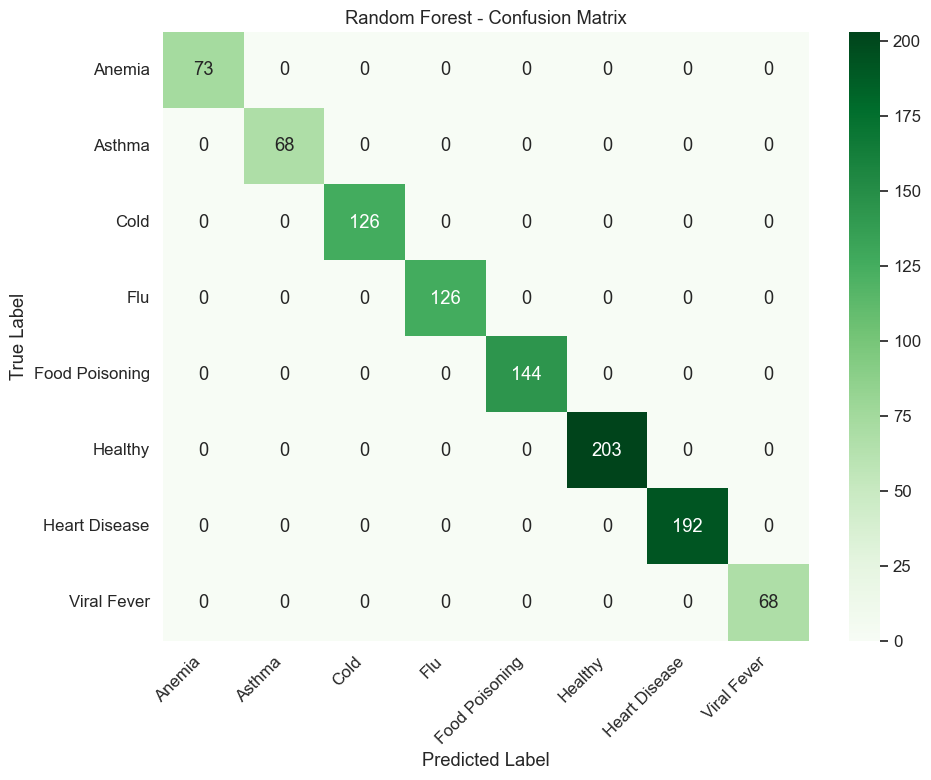

In [18]:
# Random Forest Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_y_pred, labels=rf_model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [2]:
'''
flowchart TD
    Browser["Browser / Client"]
    App["Flask App (app.py)"]
    Frontend["Frontend\ntemplates + static"]
    Routes["Backend / Routes"]
    Controllers["Backend / Controllers"]
    Models["Backend / Models"]
    DB["Database\n(schema.sql / SQLite)"]
    ML["ML Model\n(ml_model)"]
    Uploads["Uploads / Files"]

    Browser -->|HTTP GET/POST| App
    App --> Frontend
    App --> Routes
    Routes --> Controllers
    Controllers --> Models
    Models --> DB
    Routes -->|prediction request| ML
    ML --> DB
    App -->|stores uploaded files| Uploads
    Browser -->|uploads/downloads| Uploads
'''

'\nflowchart TD\n    Browser["Browser / Client"]\n    App["Flask App (app.py)"]\n    Frontend["Frontend\ntemplates + static"]\n    Routes["Backend / Routes"]\n    Controllers["Backend / Controllers"]\n    Models["Backend / Models"]\n    DB["Database\n(schema.sql / SQLite)"]\n    ML["ML Model\n(ml_model)"]\n    Uploads["Uploads / Files"]\n\n    Browser -->|HTTP GET/POST| App\n    App --> Frontend\n    App --> Routes\n    Routes --> Controllers\n    Controllers --> Models\n    Models --> DB\n    Routes -->|prediction request| ML\n    ML --> DB\n    App -->|stores uploaded files| Uploads\n    Browser -->|uploads/downloads| Uploads\n'

In [ ]:
'''
flowchart TD
    Browser["Browser / Client"]
    App["Flask App (app.py)"]
    Frontend["Frontend\ntemplates + static"]
    Routes["Backend / Routes"]
    Controllers["Backend / Controllers"]
    Models["Backend / Models"]
    DB["Database\n(schema.sql / SQLite)"]
    ML["ML Model\n(ml_model)"]
    Uploads["Uploads / Files"]

    Browser -->|HTTP GET/POST| App
    App --> Frontend
    App --> Routes
    Routes --> Controllers
    Controllers --> Models
    Models --> DB
    Routes -->|prediction request| ML
    ML --> DB
    App -->|stores uploaded files| Uploads
    Browser -->|uploads/downloads| Uploads
'''

C:\Users\chand\AppData\Local\Temp\ipykernel_19304\2216234628.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_feature_importance, x='importance', y='feature', palette='viridis')


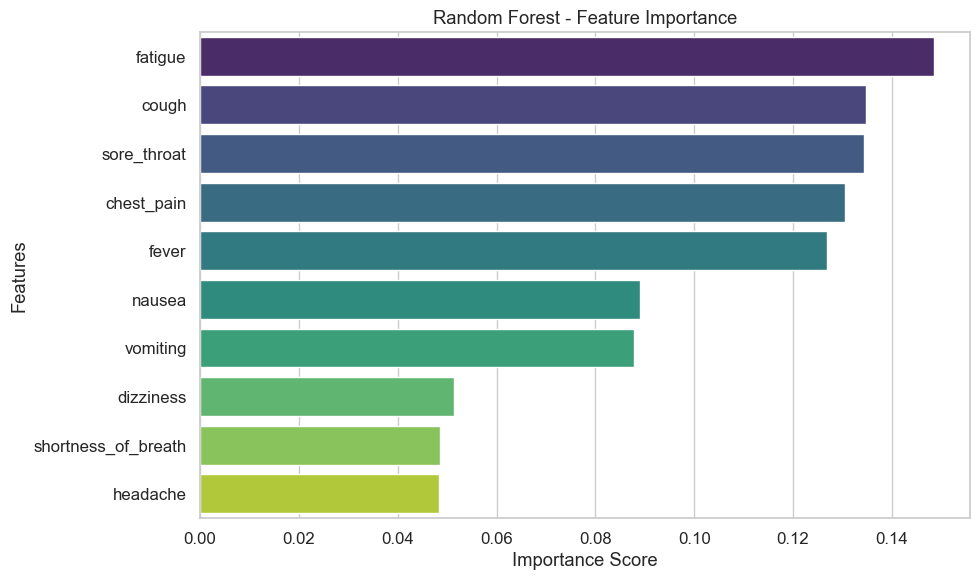

Top 5 Most Important Features (Random Forest):


,feature,importance
3,fatigue,0.148471
1,cough,0.134766
9,sore_throat,0.134280
6,chest_pain,0.130608
0,fever,0.126782


In [20]:
# Random Forest Feature Importance
rf_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features (Random Forest):")
display(rf_feature_importance.head())

,Class,Precision,Recall,F1-Score,Support
0,Anemia,1.0,1.0,1.0,73
1,Asthma,1.0,1.0,1.0,68
2,Cold,1.0,1.0,1.0,126
3,Flu,1.0,1.0,1.0,126
4,Food Poisoning,1.0,1.0,1.0,144
5,Healthy,1.0,1.0,1.0,203
6,Heart Disease,1.0,1.0,1.0,192
7,Viral Fever,1.0,1.0,1.0,68


C:\Users\chand\AppData\Local\Temp\ipykernel_19304\1253350174.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_class_metrics, x='Class', y='Precision', ax=axes[0], palette='Blues')
C:\Users\chand\AppData\Local\Temp\ipykernel_19304\1253350174.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\chand\AppData\Local\Temp\ipykernel_19304\1253350174.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_class_metrics, x='Class', y='Recall', ax=axes[1], palette='Greens')
C:\Users\chand\AppData\Local\Temp\ipykerne

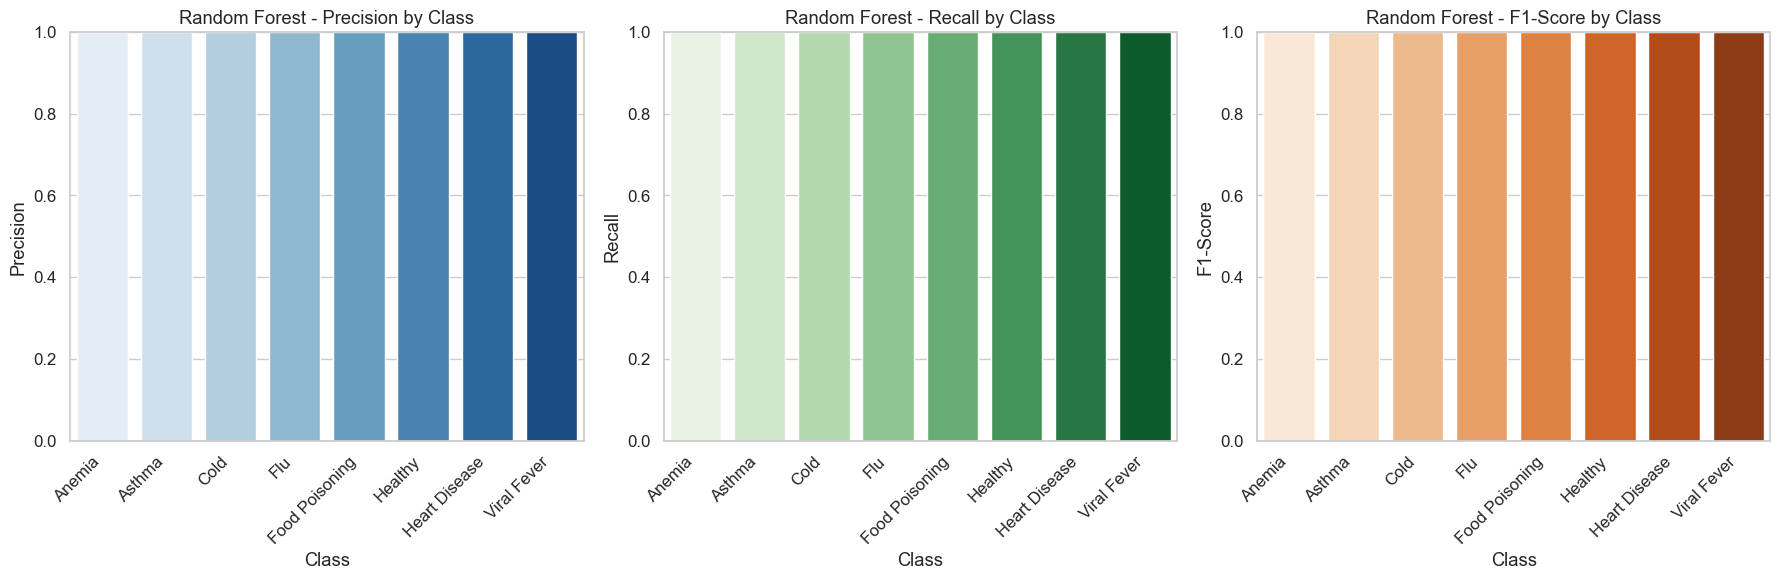

In [22]:
# Random Forest Per-Class Performance
rf_precision, rf_recall, rf_fscore, rf_support = precision_recall_fscore_support(y_test, rf_y_pred, average=None, labels=rf_model.classes_)

rf_class_metrics = pd.DataFrame({
    'Class': rf_model.classes_,
    'Precision': rf_precision,
    'Recall': rf_recall,
    'F1-Score': rf_fscore,
    'Support': rf_support
}).round(4)

display(rf_class_metrics)

# Plot RF per-class metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=rf_class_metrics, x='Class', y='Precision', ax=axes[0], palette='Blues')
axes[0].set_title('Random Forest - Precision by Class')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylim(0, 1)

sns.barplot(data=rf_class_metrics, x='Class', y='Recall', ax=axes[1], palette='Greens')
axes[1].set_title('Random Forest - Recall by Class')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylim(0, 1)

sns.barplot(data=rf_class_metrics, x='Class', y='F1-Score', ax=axes[2], palette='Oranges')
axes[2].set_title('Random Forest - F1-Score by Class')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Detailed Analysis: Gradient Boosting Classifier

This section analyzes the Gradient Boosting model, focusing on boosting characteristics, learning curves, and performance metrics.

In [23]:
# Gradient Boosting Performance Analysis
gb_model = trained_models['Gradient Boosting']

gb_y_pred = gb_model.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_y_pred)
gb_f1 = f1_score(y_test, gb_y_pred, average='weighted')

print("=== Gradient Boosting Performance ===")
print(f"Accuracy: {gb_accuracy:.4f}")
print(f"Weighted F1 Score: {gb_f1:.4f}")
print(f"Number of Estimators: {gb_model.n_estimators_}")
print(f"Learning Rate: {gb_model.learning_rate}")
print(f"Max Depth: {gb_model.max_depth}")
print(f"Number of Features: {gb_model.n_features_in_}")

print("\nClassification Report:")
print(classification_report(y_test, gb_y_pred, zero_division=0))

=== Gradient Boosting Performance ===
Accuracy: 1.0000
Weighted F1 Score: 1.0000
Number of Estimators: 100
Learning Rate: 0.1
Max Depth: 3
Number of Features: 10

Classification Report:
                precision    recall  f1-score   support

        Anemia       1.00      1.00      1.00        73
        Asthma       1.00      1.00      1.00        68
          Cold       1.00      1.00      1.00       126
           Flu       1.00      1.00      1.00       126
Food Poisoning       1.00      1.00      1.00       144
       Healthy       1.00      1.00      1.00       203
 Heart Disease       1.00      1.00      1.00       192
   Viral Fever       1.00      1.00      1.00        68

      accuracy                           1.00      1000
     macro avg       1.00      1.00      1.00      1000
  weighted avg       1.00      1.00      1.00      1000



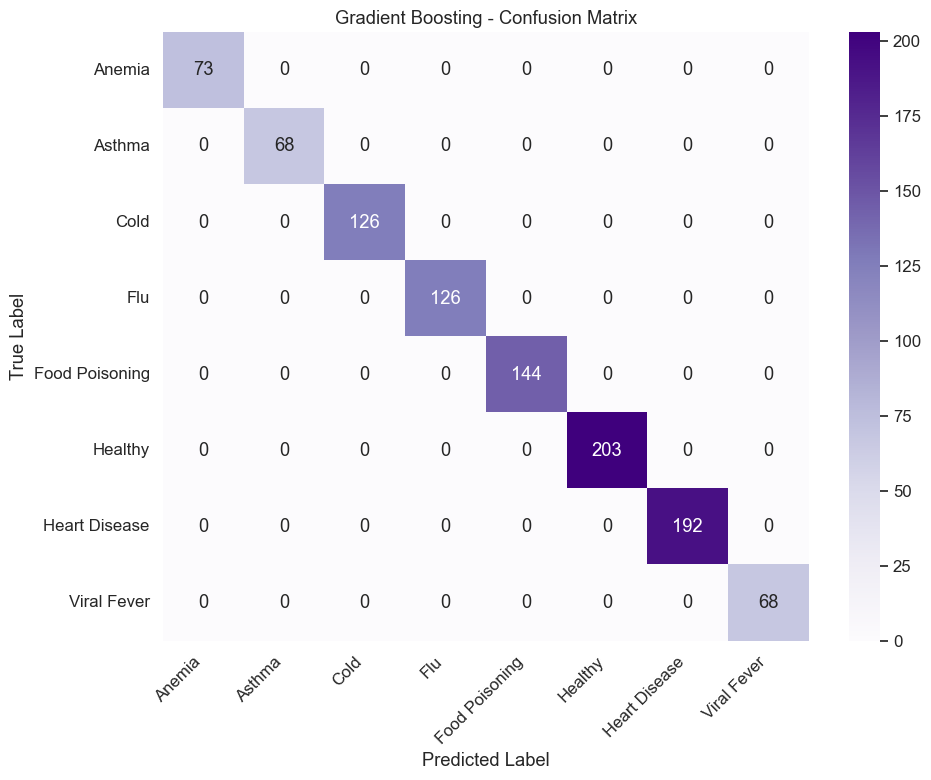

In [24]:
# Gradient Boosting Confusion Matrix
gb_cm = confusion_matrix(y_test, gb_y_pred, labels=gb_model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(gb_cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=gb_model.classes_,
            yticklabels=gb_model.classes_)
plt.title('Gradient Boosting - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\chand\AppData\Local\Temp\ipykernel_19304\2678281710.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gb_feature_importance, x='importance', y='feature', palette='viridis')


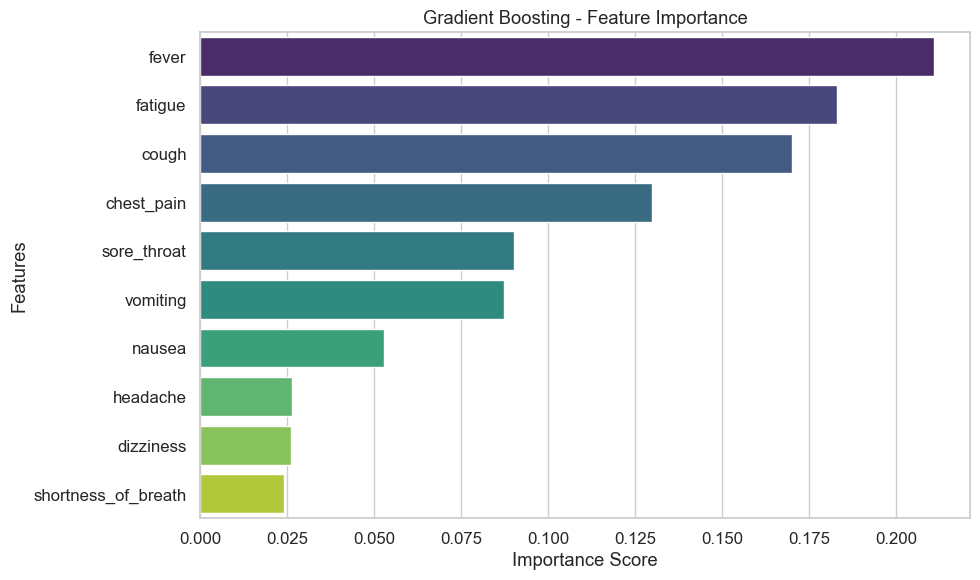

Top 5 Most Important Features (Gradient Boosting):


,feature,importance
0,fever,0.210708
3,fatigue,0.182790
1,cough,0.169990
6,chest_pain,0.129710
9,sore_throat,0.090174


In [25]:
# Gradient Boosting Feature Importance
gb_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=gb_feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Gradient Boosting - Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features (Gradient Boosting):")
display(gb_feature_importance.head())

,Class,Precision,Recall,F1-Score,Support
0,Anemia,1.0,1.0,1.0,73
1,Asthma,1.0,1.0,1.0,68
2,Cold,1.0,1.0,1.0,126
3,Flu,1.0,1.0,1.0,126
4,Food Poisoning,1.0,1.0,1.0,144
5,Healthy,1.0,1.0,1.0,203
6,Heart Disease,1.0,1.0,1.0,192
7,Viral Fever,1.0,1.0,1.0,68


C:\Users\chand\AppData\Local\Temp\ipykernel_19304\3564033129.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gb_class_metrics, x='Class', y='Precision', ax=axes[0], palette='Blues')
C:\Users\chand\AppData\Local\Temp\ipykernel_19304\3564033129.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\chand\AppData\Local\Temp\ipykernel_19304\3564033129.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gb_class_metrics, x='Class', y='Recall', ax=axes[1], palette='Greens')
C:\Users\chand\AppData\Local\Temp\ipykerne

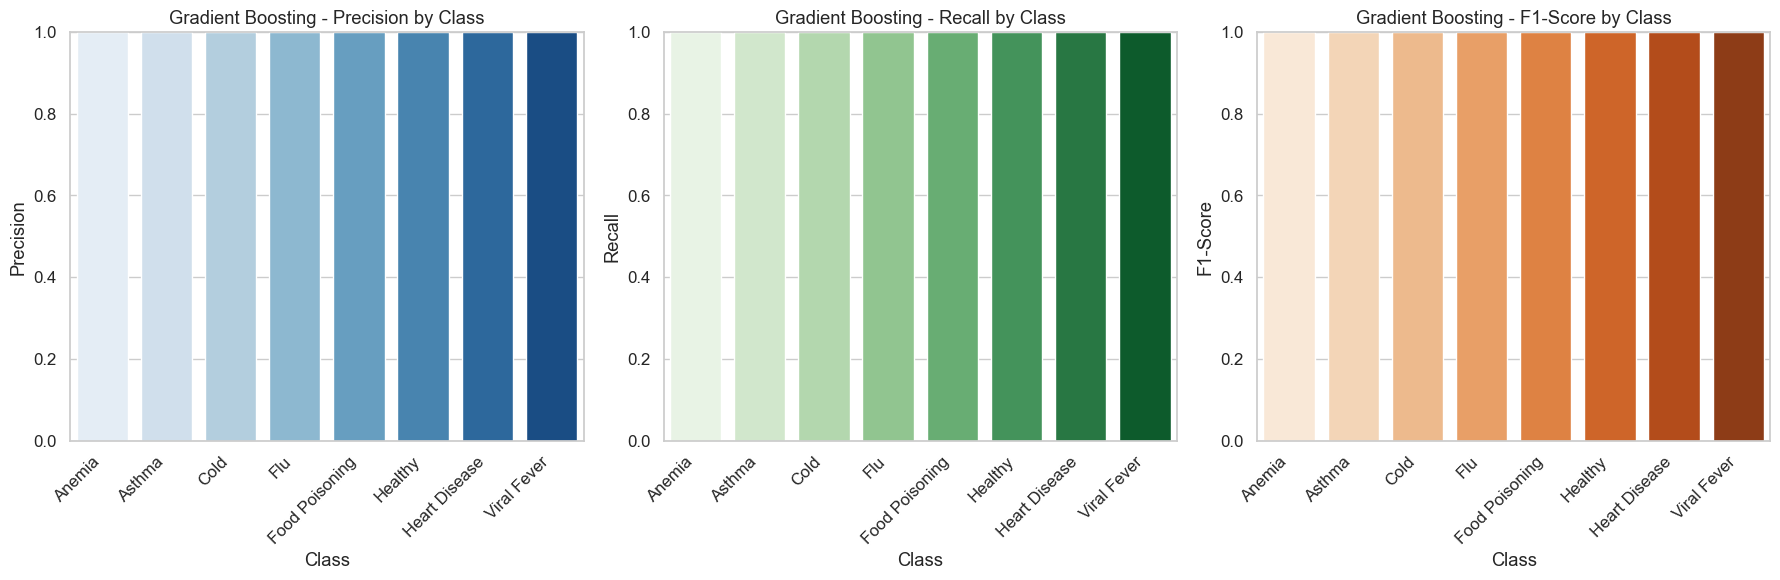

In [26]:
# Gradient Boosting Per-Class Performance
gb_precision, gb_recall, gb_fscore, gb_support = precision_recall_fscore_support(y_test, gb_y_pred, average=None, labels=gb_model.classes_)

gb_class_metrics = pd.DataFrame({
    'Class': gb_model.classes_,
    'Precision': gb_precision,
    'Recall': gb_recall,
    'F1-Score': gb_fscore,
    'Support': gb_support
}).round(4)

display(gb_class_metrics)

# Plot GB per-class metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=gb_class_metrics, x='Class', y='Precision', ax=axes[0], palette='Blues')
axes[0].set_title('Gradient Boosting - Precision by Class')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylim(0, 1)

sns.barplot(data=gb_class_metrics, x='Class', y='Recall', ax=axes[1], palette='Greens')
axes[1].set_title('Gradient Boosting - Recall by Class')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylim(0, 1)

sns.barplot(data=gb_class_metrics, x='Class', y='F1-Score', ax=axes[2], palette='Oranges')
axes[2].set_title('Gradient Boosting - F1-Score by Class')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Detailed Analysis: Logistic Regression

This section examines the Logistic Regression model, including coefficients interpretation, probability outputs, and linear decision boundaries.

In [27]:
# Logistic Regression Performance Analysis
lr_model = trained_models['Logistic Regression']

lr_y_pred = lr_model.predict(X_test)
lr_y_pred_proba = lr_model.predict_proba(X_test)
lr_accuracy = accuracy_score(y_test, lr_y_pred)
lr_f1 = f1_score(y_test, lr_y_pred, average='weighted')

print("=== Logistic Regression Performance ===")
print(f"Accuracy: {lr_accuracy:.4f}")
print(f"Weighted F1 Score: {lr_f1:.4f}")
print(f"Solver: {lr_model.solver}")
print(f"Max Iterations: {lr_model.max_iter}")
print(f"Convergence: {lr_model.n_iter_} iterations")
print(f"Number of Features: {lr_model.n_features_in_}")

print("\nClassification Report:")
print(classification_report(y_test, lr_y_pred, zero_division=0))

=== Logistic Regression Performance ===
Accuracy: 1.0000
Weighted F1 Score: 1.0000
Solver: lbfgs
Max Iterations: 1000
Convergence: [41] iterations
Number of Features: 10

Classification Report:
                precision    recall  f1-score   support

        Anemia       1.00      1.00      1.00        73
        Asthma       1.00      1.00      1.00        68
          Cold       1.00      1.00      1.00       126
           Flu       1.00      1.00      1.00       126
Food Poisoning       1.00      1.00      1.00       144
       Healthy       1.00      1.00      1.00       203
 Heart Disease       1.00      1.00      1.00       192
   Viral Fever       1.00      1.00      1.00        68

      accuracy                           1.00      1000
     macro avg       1.00      1.00      1.00      1000
  weighted avg       1.00      1.00      1.00      1000



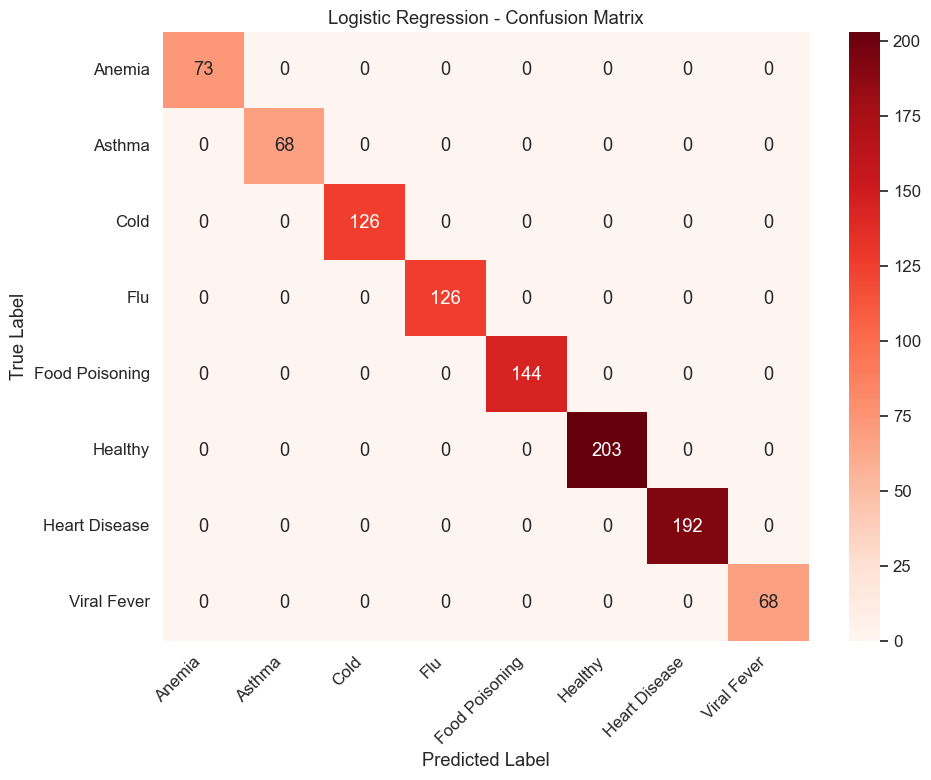

In [28]:
# Logistic Regression Confusion Matrix
lr_cm = confusion_matrix(y_test, lr_y_pred, labels=lr_model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=lr_model.classes_,
            yticklabels=lr_model.classes_)
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Logistic Regression Coefficients (features x classes):


,Anemia,Asthma,Cold,Flu,Food Poisoning,Healthy,Heart Disease,Viral Fever
fever,-0.529127,-0.440727,-5.156088,4.251687,-0.505161,-1.799683,-0.477586,4.656686
cough,-2.109179,-2.154864,6.874595,6.886913,-2.588333,-2.164334,-2.755508,-1.989291
headache,-0.541034,-0.419995,-0.830769,-0.076426,-0.467719,-1.818966,-0.497134,4.652043
fatigue,4.458519,-3.769200,-0.270915,-0.260470,-1.985535,-2.503021,6.945209,-2.614587
nausea,-1.861153,-1.882388,-0.103546,-0.036191,6.680439,-1.384268,0.160303,-1.573197
vomiting,-1.777047,-1.806104,-0.181176,-0.101741,6.740934,-1.530469,0.116571,-1.460968
chest_pain,-3.876156,4.454375,-0.242287,-0.251447,-1.975654,-2.511580,7.027140,-2.624391
shortness_of_breath,-0.759397,5.292988,-0.286542,-0.410059,-0.513144,-1.534053,-0.238738,-1.551055
dizziness,5.362738,-0.896823,-0.276386,-0.381955,-0.405892,-1.576247,-0.241476,-1.583959
sore_throat,-2.070085,-2.199450,6.843819,6.933670,-2.606687,-2.021034,-2.740780,-2.139453


C:\Users\chand\AppData\Local\Temp\ipykernel_19304\783415836.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs.values, y=coefs.index, ax=axes[i], palette='coolwarm')
C:\Users\chand\AppData\Local\Temp\ipykernel_19304\783415836.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs.values, y=coefs.index, ax=axes[i], palette='coolwarm')
C:\Users\chand\AppData\Local\Temp\ipykernel_19304\783415836.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs.values, y=coefs.index, ax=axes[i], palette='coolwarm')
C:\Users\chand\AppD

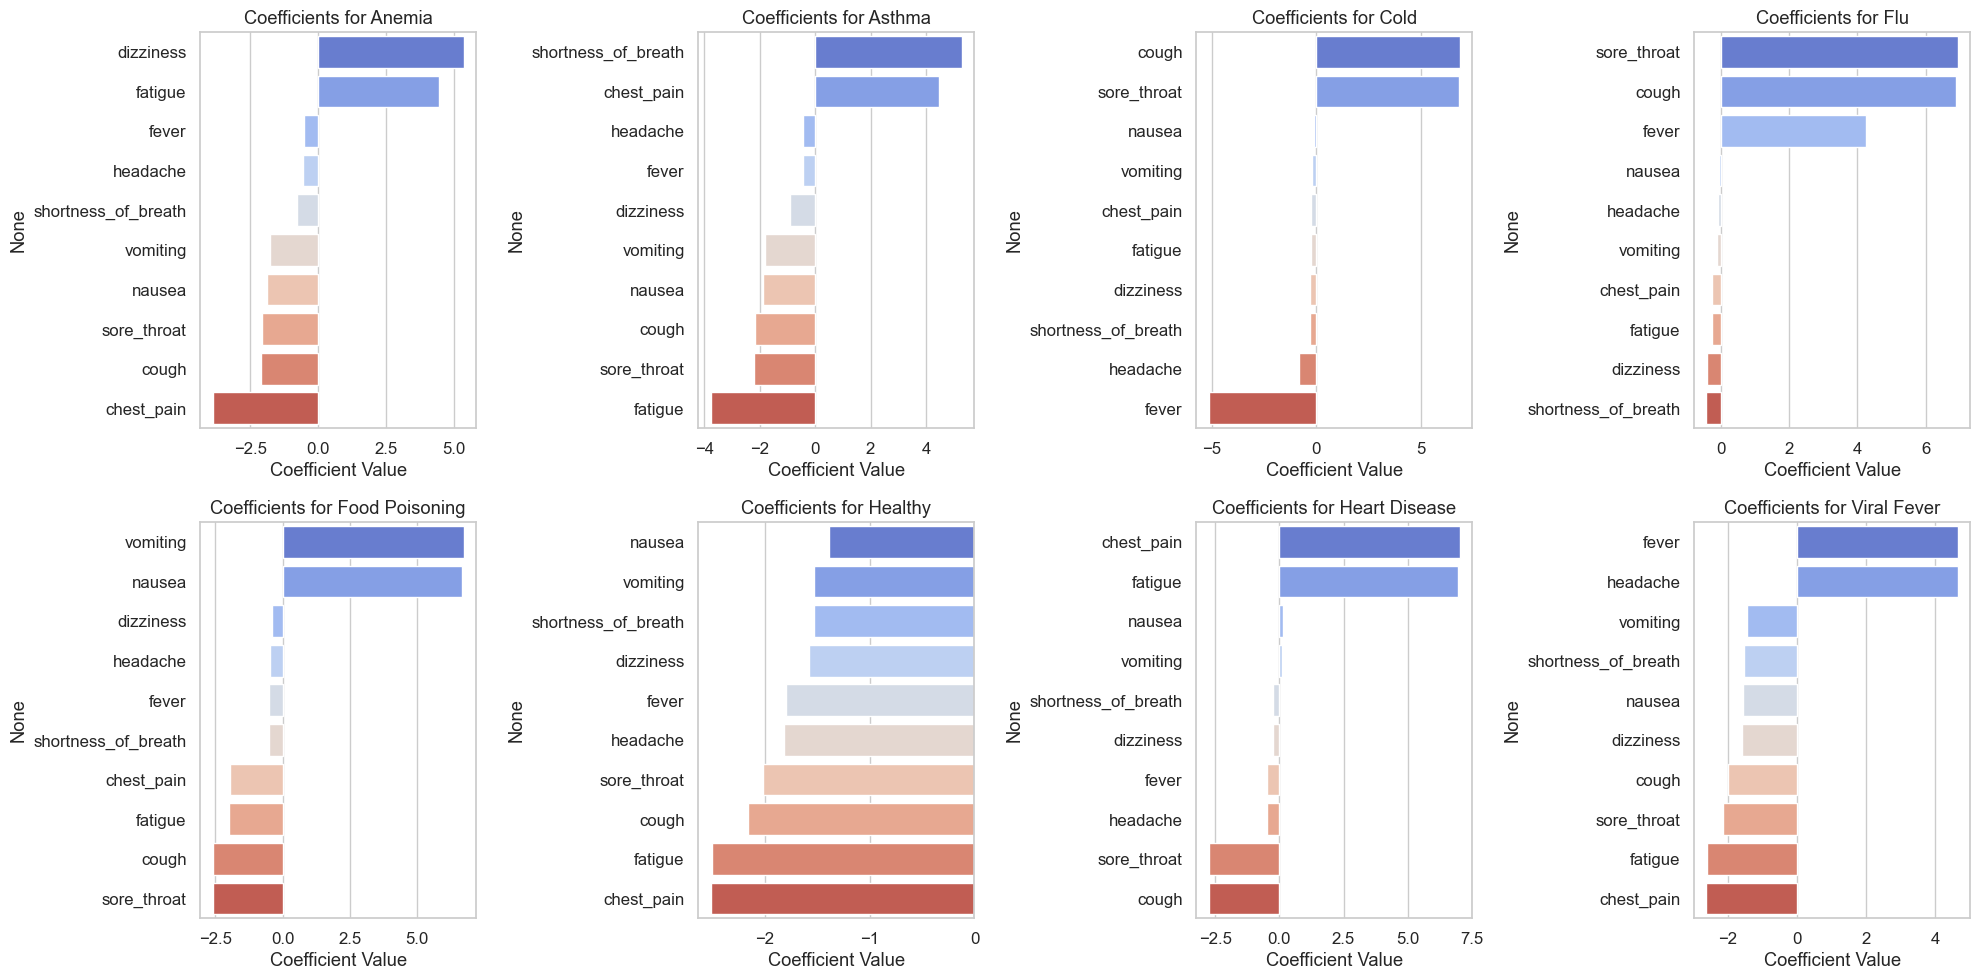

In [29]:
# Logistic Regression Coefficients Analysis
# Since LR is multiclass, we show coefficients for each class
lr_coef_df = pd.DataFrame(lr_model.coef_.T, columns=lr_model.classes_, index=X.columns)
print("Logistic Regression Coefficients (features x classes):")
display(lr_coef_df)

# Plot coefficients for each class
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, class_name in enumerate(lr_model.classes_):
    coefs = lr_coef_df[class_name].sort_values(ascending=False)
    sns.barplot(x=coefs.values, y=coefs.index, ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'Coefficients for {class_name}')
    axes[i].set_xlabel('Coefficient Value')

for j in range(len(lr_model.classes_), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

,Class,Precision,Recall,F1-Score,Support
0,Anemia,1.0,1.0,1.0,73
1,Asthma,1.0,1.0,1.0,68
2,Cold,1.0,1.0,1.0,126
3,Flu,1.0,1.0,1.0,126
4,Food Poisoning,1.0,1.0,1.0,144
5,Healthy,1.0,1.0,1.0,203
6,Heart Disease,1.0,1.0,1.0,192
7,Viral Fever,1.0,1.0,1.0,68


C:\Users\chand\AppData\Local\Temp\ipykernel_19304\304388711.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lr_class_metrics, x='Class', y='Precision', ax=axes[0], palette='Blues')
C:\Users\chand\AppData\Local\Temp\ipykernel_19304\304388711.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\chand\AppData\Local\Temp\ipykernel_19304\304388711.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lr_class_metrics, x='Class', y='Recall', ax=axes[1], palette='Greens')
C:\Users\chand\AppData\Local\Temp\ipykernel_1

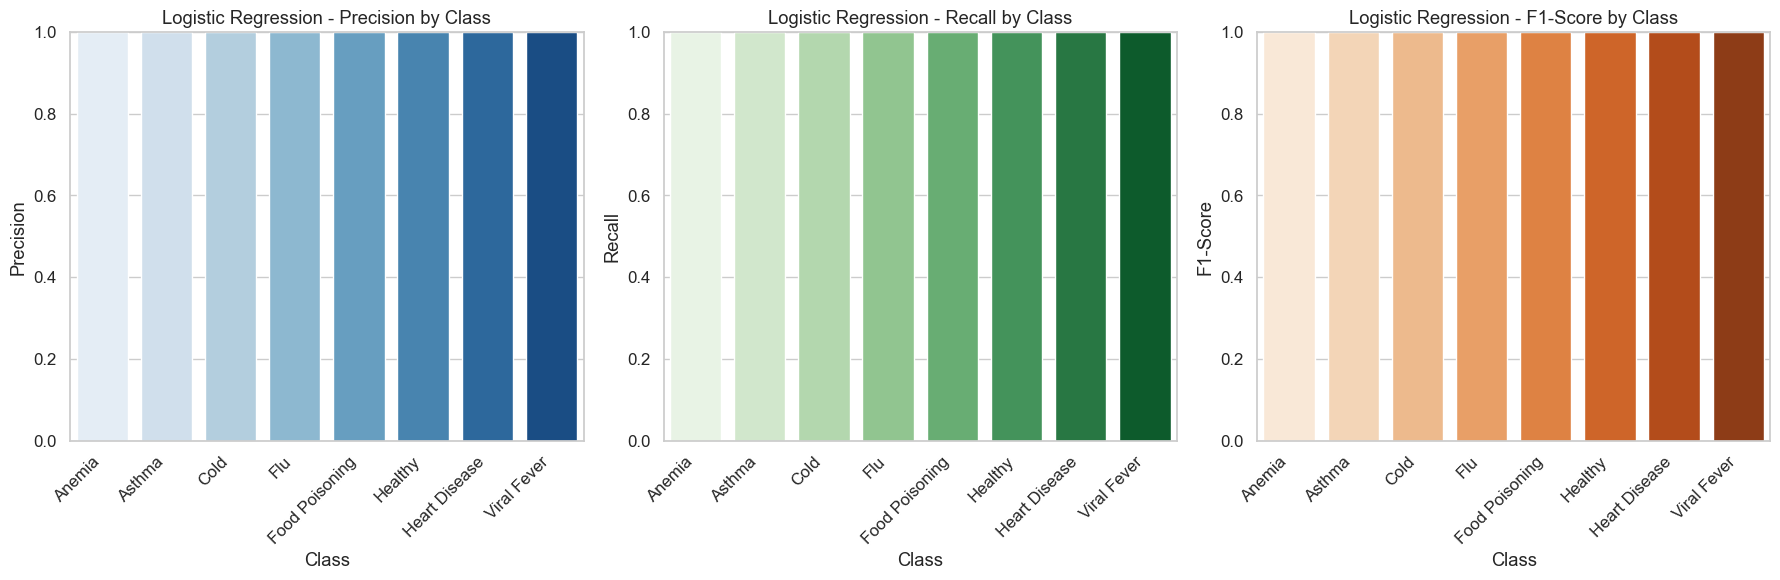

In [30]:
# Logistic Regression Per-Class Performance
lr_precision, lr_recall, lr_fscore, lr_support = precision_recall_fscore_support(y_test, lr_y_pred, average=None, labels=lr_model.classes_)

lr_class_metrics = pd.DataFrame({
    'Class': lr_model.classes_,
    'Precision': lr_precision,
    'Recall': lr_recall,
    'F1-Score': lr_fscore,
    'Support': lr_support
}).round(4)

display(lr_class_metrics)

# Plot LR per-class metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=lr_class_metrics, x='Class', y='Precision', ax=axes[0], palette='Blues')
axes[0].set_title('Logistic Regression - Precision by Class')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylim(0, 1)

sns.barplot(data=lr_class_metrics, x='Class', y='Recall', ax=axes[1], palette='Greens')
axes[1].set_title('Logistic Regression - Recall by Class')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylim(0, 1)

sns.barplot(data=lr_class_metrics, x='Class', y='F1-Score', ax=axes[2], palette='Oranges')
axes[2].set_title('Logistic Regression - F1-Score by Class')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Detailed Analysis: Support Vector Machine (SVM)

This section analyzes the SVM model, including kernel type, support vectors, and decision function characteristics.

In [31]:
# SVM Performance Analysis
svm_model = trained_models['Support Vector Machine']

svm_y_pred = svm_model.predict(X_test)
svm_y_pred_proba = svm_model.predict_proba(X_test)
svm_accuracy = accuracy_score(y_test, svm_y_pred)
svm_f1 = f1_score(y_test, svm_y_pred, average='weighted')

print("=== Support Vector Machine Performance ===")
print(f"Accuracy: {svm_accuracy:.4f}")
print(f"Weighted F1 Score: {svm_f1:.4f}")
print(f"Kernel: {svm_model.kernel}")
print(f"C (Regularization): {svm_model.C}")
print(f"Gamma: {svm_model.gamma}")
print(f"Number of Support Vectors: {svm_model.n_support_}")
print(f"Total Support Vectors: {sum(svm_model.n_support_)}")
print(f"Number of Features: {svm_model.n_features_in_}")

print("\nClassification Report:")
print(classification_report(y_test, svm_y_pred, zero_division=0))

=== Support Vector Machine Performance ===
Accuracy: 1.0000
Weighted F1 Score: 1.0000
Kernel: rbf
C (Regularization): 1.0
Gamma: scale
Number of Support Vectors: [ 77  81 191 184 235 333 362 134]
Total Support Vectors: 1597
Number of Features: 10

Classification Report:
                precision    recall  f1-score   support

        Anemia       1.00      1.00      1.00        73
        Asthma       1.00      1.00      1.00        68
          Cold       1.00      1.00      1.00       126
           Flu       1.00      1.00      1.00       126
Food Poisoning       1.00      1.00      1.00       144
       Healthy       1.00      1.00      1.00       203
 Heart Disease       1.00      1.00      1.00       192
   Viral Fever       1.00      1.00      1.00        68

      accuracy                           1.00      1000
     macro avg       1.00      1.00      1.00      1000
  weighted avg       1.00      1.00      1.00      1000



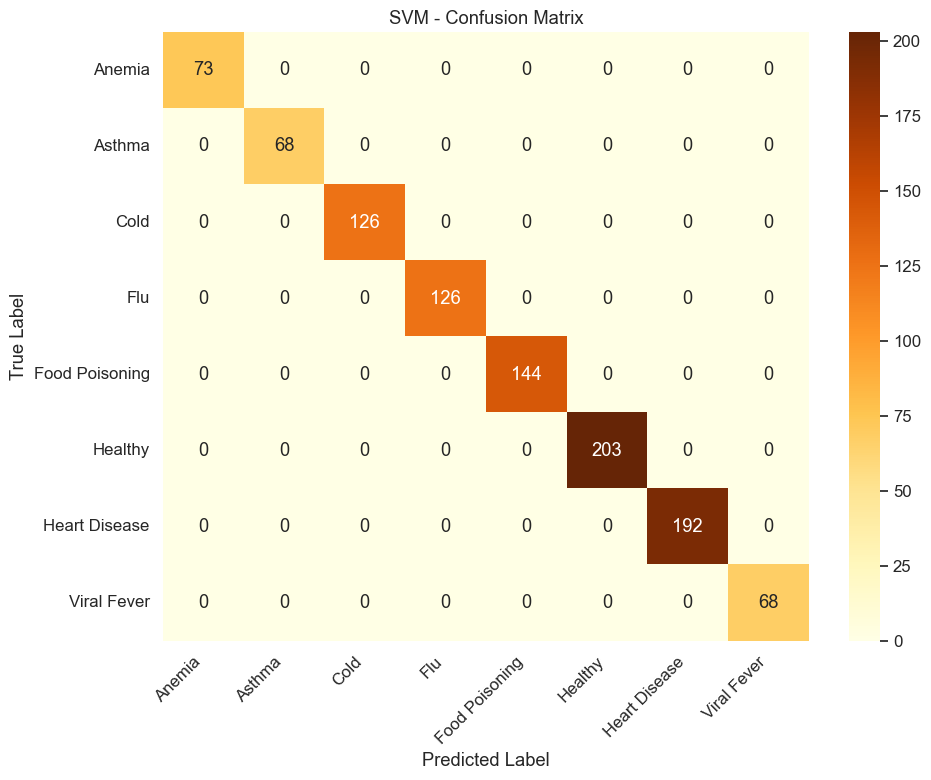

In [32]:
# SVM Confusion Matrix
svm_cm = confusion_matrix(y_test, svm_y_pred, labels=svm_model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)
plt.title('SVM - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Support Vectors per Class:
Anemia: 77 support vectors
Asthma: 81 support vectors
Cold: 191 support vectors
Flu: 184 support vectors
Food Poisoning: 235 support vectors
Healthy: 333 support vectors
Heart Disease: 362 support vectors
Viral Fever: 134 support vectors

Total Support Vectors: 1597
Support Vectors as % of Training Data: 39.92%


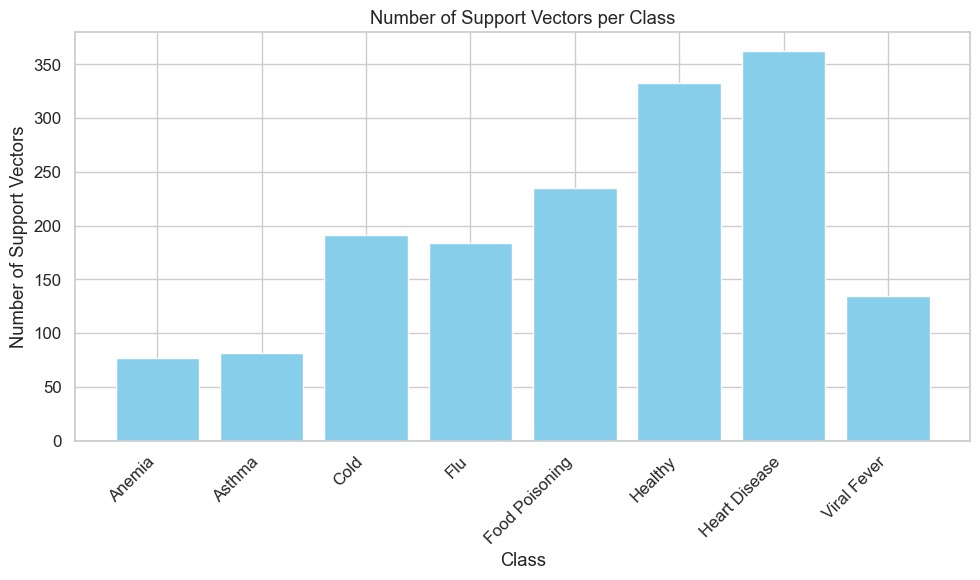

In [33]:
# SVM Support Vectors Analysis
print("Support Vectors per Class:")
for i, class_name in enumerate(svm_model.classes_):
    print(f"{class_name}: {svm_model.n_support_[i]} support vectors")

print(f"\nTotal Support Vectors: {sum(svm_model.n_support_)}")
print(f"Support Vectors as % of Training Data: {sum(svm_model.n_support_) / len(X_train) * 100:.2f}%")

# Plot support vectors distribution
plt.figure(figsize=(10, 6))
plt.bar(svm_model.classes_, svm_model.n_support_, color='skyblue')
plt.title('Number of Support Vectors per Class')
plt.xlabel('Class')
plt.ylabel('Number of Support Vectors')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

,Class,Precision,Recall,F1-Score,Support
0,Anemia,1.0,1.0,1.0,73
1,Asthma,1.0,1.0,1.0,68
2,Cold,1.0,1.0,1.0,126
3,Flu,1.0,1.0,1.0,126
4,Food Poisoning,1.0,1.0,1.0,144
5,Healthy,1.0,1.0,1.0,203
6,Heart Disease,1.0,1.0,1.0,192
7,Viral Fever,1.0,1.0,1.0,68


C:\Users\chand\AppData\Local\Temp\ipykernel_19304\2332459603.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=svm_class_metrics, x='Class', y='Precision', ax=axes[0], palette='Blues')
C:\Users\chand\AppData\Local\Temp\ipykernel_19304\2332459603.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\chand\AppData\Local\Temp\ipykernel_19304\2332459603.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=svm_class_metrics, x='Class', y='Recall', ax=axes[1], palette='Greens')
C:\Users\chand\AppData\Local\Temp\ipyker

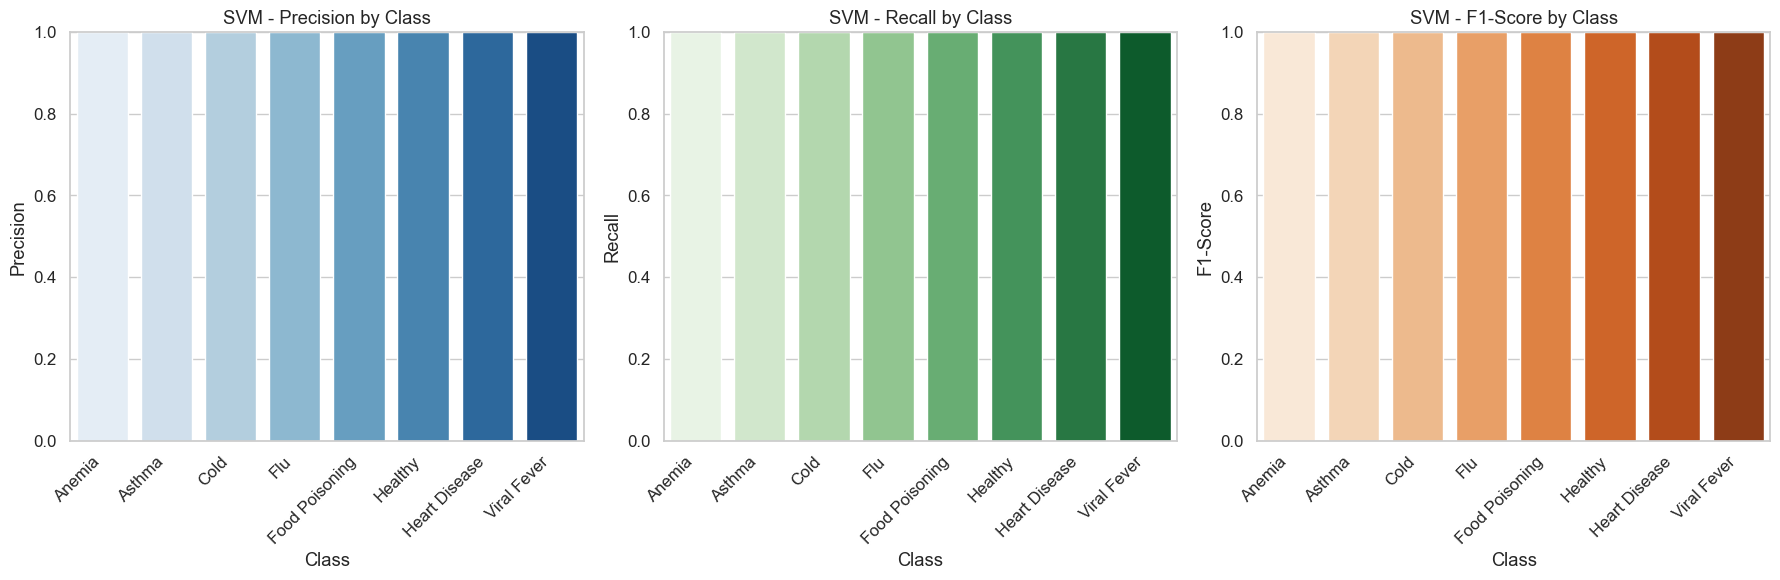

In [34]:
# SVM Per-Class Performance
svm_precision, svm_recall, svm_fscore, svm_support = precision_recall_fscore_support(y_test, svm_y_pred, average=None, labels=svm_model.classes_)

svm_class_metrics = pd.DataFrame({
    'Class': svm_model.classes_,
    'Precision': svm_precision,
    'Recall': svm_recall,
    'F1-Score': svm_fscore,
    'Support': svm_support
}).round(4)

display(svm_class_metrics)

# Plot SVM per-class metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=svm_class_metrics, x='Class', y='Precision', ax=axes[0], palette='Blues')
axes[0].set_title('SVM - Precision by Class')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylim(0, 1)

sns.barplot(data=svm_class_metrics, x='Class', y='Recall', ax=axes[1], palette='Greens')
axes[1].set_title('SVM - Recall by Class')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylim(0, 1)

sns.barplot(data=svm_class_metrics, x='Class', y='F1-Score', ax=axes[2], palette='Oranges')
axes[2].set_title('SVM - F1-Score by Class')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Detailed Analysis: K-Nearest Neighbors (KNN)

This section examines the KNN model, including neighbor analysis, distance metrics, and instance-based learning characteristics.

In [35]:
# KNN Performance Analysis
knn_model = trained_models['K-Nearest Neighbors']

knn_y_pred = knn_model.predict(X_test)
knn_y_pred_proba = knn_model.predict_proba(X_test)
knn_accuracy = accuracy_score(y_test, knn_y_pred)
knn_f1 = f1_score(y_test, knn_y_pred, average='weighted')

print("=== K-Nearest Neighbors Performance ===")
print(f"Accuracy: {knn_accuracy:.4f}")
print(f"Weighted F1 Score: {knn_f1:.4f}")
print(f"Number of Neighbors (k): {knn_model.n_neighbors}")
print(f"Distance Metric: {knn_model.metric}")
print(f"Algorithm: {knn_model.algorithm}")
print(f"Number of Features: {knn_model.n_features_in_}")
print(f"Training Samples: {knn_model.n_samples_fit_}")

print("\nClassification Report:")
print(classification_report(y_test, knn_y_pred, zero_division=0))

=== K-Nearest Neighbors Performance ===
Accuracy: 0.9770
Weighted F1 Score: 0.9769
Number of Neighbors (k): 5
Distance Metric: minkowski
Algorithm: auto
Number of Features: 10
Training Samples: 4000

Classification Report:
                precision    recall  f1-score   support

        Anemia       0.99      1.00      0.99        73
        Asthma       0.99      0.99      0.99        68
          Cold       0.99      1.00      1.00       126
           Flu       0.95      1.00      0.98       126
Food Poisoning       0.95      1.00      0.97       144
       Healthy       0.98      0.94      0.96       203
 Heart Disease       0.99      0.98      0.99       192
   Viral Fever       0.97      0.91      0.94        68

      accuracy                           0.98      1000
     macro avg       0.98      0.98      0.98      1000
  weighted avg       0.98      0.98      0.98      1000



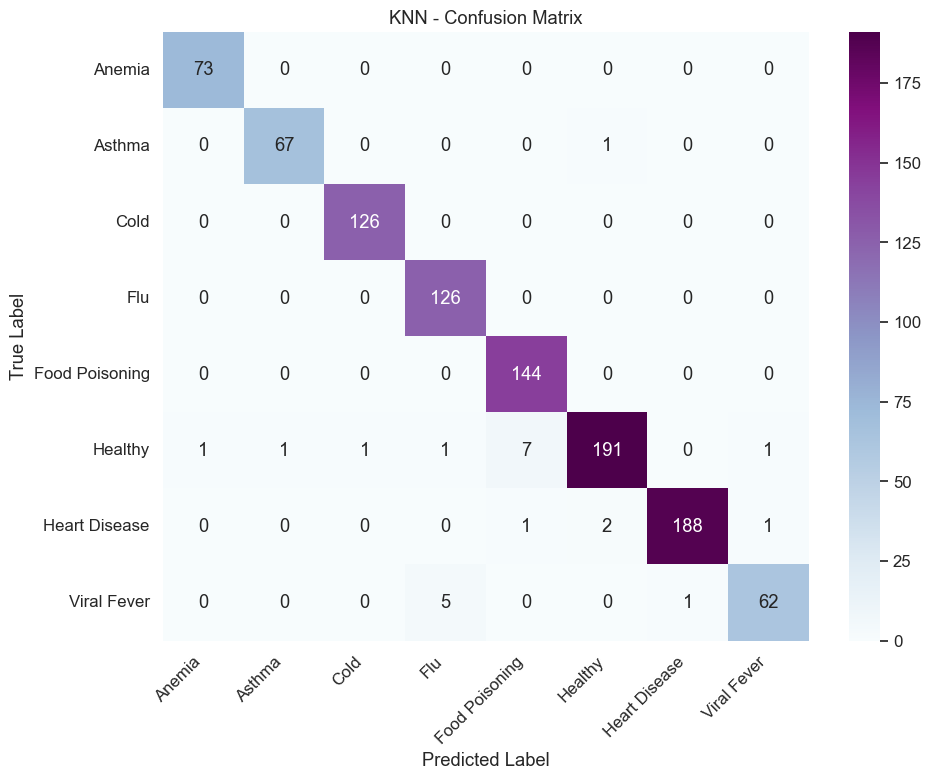

In [36]:
# KNN Confusion Matrix
knn_cm = confusion_matrix(y_test, knn_y_pred, labels=knn_model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='BuPu',
            xticklabels=knn_model.classes_,
            yticklabels=knn_model.classes_)
plt.title('KNN - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

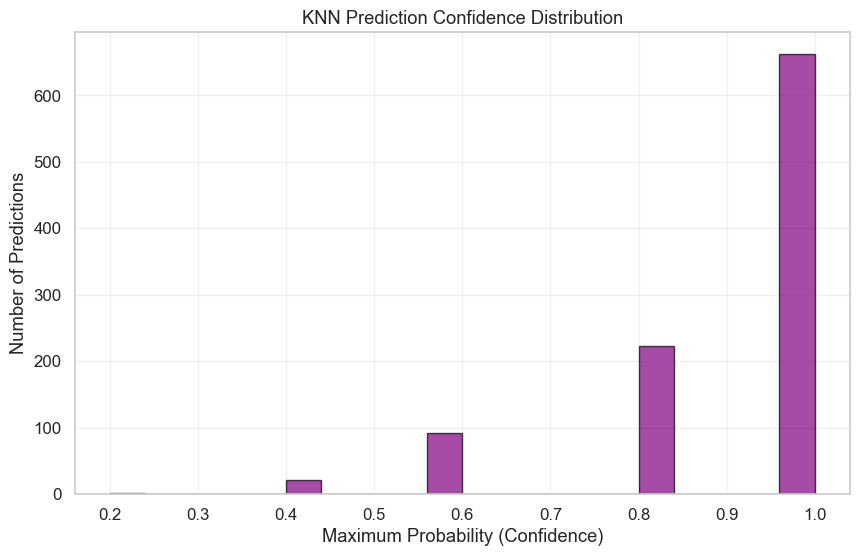

Average Prediction Confidence: 0.9044
Median Prediction Confidence: 1.0000
Min Prediction Confidence: 0.2000
Max Prediction Confidence: 1.0000

Examples of Low Confidence Predictions (< 0.6):
True: Anemia, Predicted: Anemia, Confidence: 0.4000
True: Healthy, Predicted: Flu, Confidence: 0.4000
True: Viral Fever, Predicted: Flu, Confidence: 0.4000
True: Healthy, Predicted: Healthy, Confidence: 0.4000
True: Healthy, Predicted: Cold, Confidence: 0.4000


In [37]:
# KNN Prediction Confidence Analysis
# Analyze the confidence of predictions (max probability)
max_probs = np.max(knn_y_pred_proba, axis=1)

plt.figure(figsize=(10, 6))
plt.hist(max_probs, bins=20, alpha=0.7, color='purple', edgecolor='black')
plt.title('KNN Prediction Confidence Distribution')
plt.xlabel('Maximum Probability (Confidence)')
plt.ylabel('Number of Predictions')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average Prediction Confidence: {max_probs.mean():.4f}")
print(f"Median Prediction Confidence: {np.median(max_probs):.4f}")
print(f"Min Prediction Confidence: {max_probs.min():.4f}")
print(f"Max Prediction Confidence: {max_probs.max():.4f}")

# Show some examples of low confidence predictions
low_conf_indices = np.where(max_probs < 0.6)[0]
if len(low_conf_indices) > 0:
    print(f"\nExamples of Low Confidence Predictions (< 0.6):")
    for idx in low_conf_indices[:5]:  # Show first 5
        true_class = y_test.iloc[idx]
        pred_class = knn_y_pred[idx]
        conf = max_probs[idx]
        print(f"True: {true_class}, Predicted: {pred_class}, Confidence: {conf:.4f}")
else:
    print("\nAll predictions have confidence >= 0.6")

,Class,Precision,Recall,F1-Score,Support
0,Anemia,0.9865,1.0000,0.9932,73
1,Asthma,0.9853,0.9853,0.9853,68
2,Cold,0.9921,1.0000,0.9960,126
3,Flu,0.9545,1.0000,0.9767,126
4,Food Poisoning,0.9474,1.0000,0.9730,144
5,Healthy,0.9845,0.9409,0.9622,203
6,Heart Disease,0.9947,0.9792,0.9869,192
7,Viral Fever,0.9688,0.9118,0.9394,68


C:\Users\chand\AppData\Local\Temp\ipykernel_19304\860764241.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=knn_class_metrics, x='Class', y='Precision', ax=axes[0], palette='Blues')
C:\Users\chand\AppData\Local\Temp\ipykernel_19304\860764241.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\chand\AppData\Local\Temp\ipykernel_19304\860764241.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=knn_class_metrics, x='Class', y='Recall', ax=axes[1], palette='Greens')
C:\Users\chand\AppData\Local\Temp\ipykernel

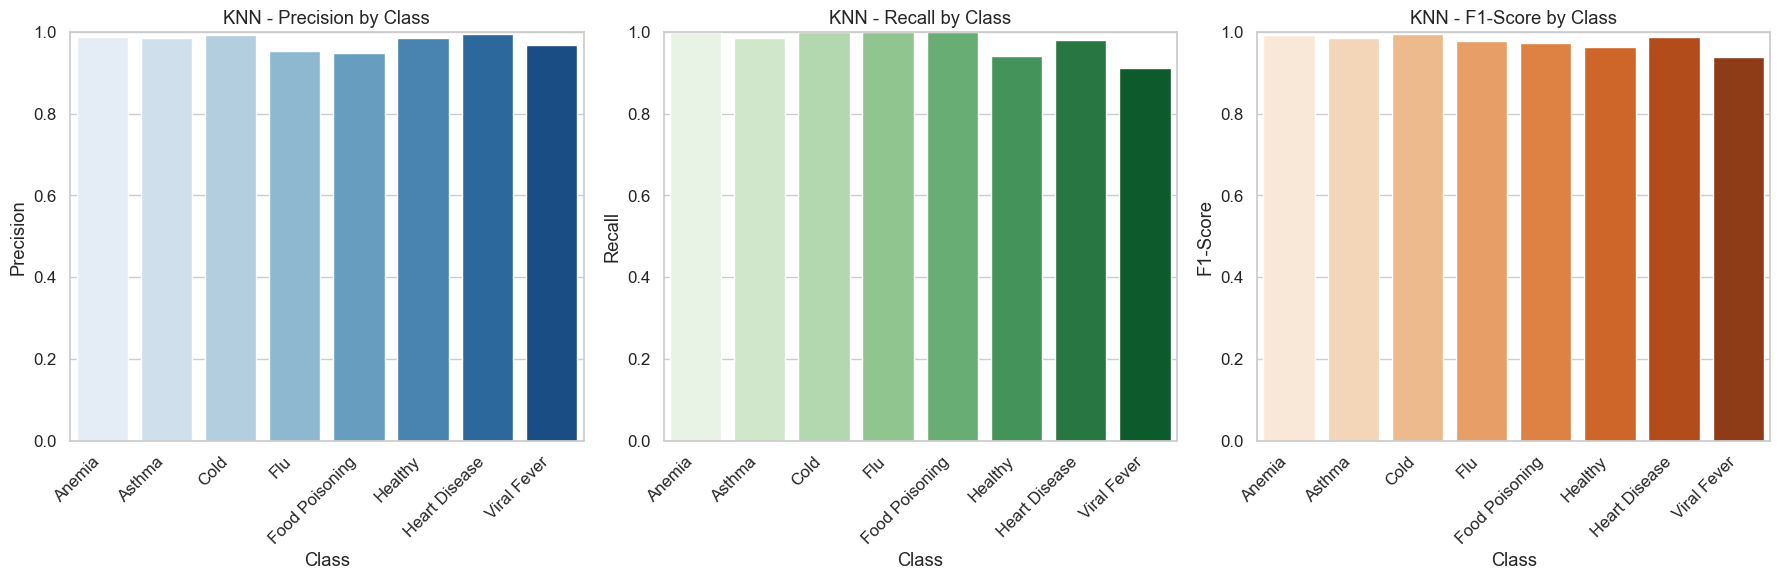

In [38]:
# KNN Per-Class Performance
knn_precision, knn_recall, knn_fscore, knn_support = precision_recall_fscore_support(y_test, knn_y_pred, average=None, labels=knn_model.classes_)

knn_class_metrics = pd.DataFrame({
    'Class': knn_model.classes_,
    'Precision': knn_precision,
    'Recall': knn_recall,
    'F1-Score': knn_fscore,
    'Support': knn_support
}).round(4)

display(knn_class_metrics)

# Plot KNN per-class metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=knn_class_metrics, x='Class', y='Precision', ax=axes[0], palette='Blues')
axes[0].set_title('KNN - Precision by Class')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylim(0, 1)

sns.barplot(data=knn_class_metrics, x='Class', y='Recall', ax=axes[1], palette='Greens')
axes[1].set_title('KNN - Recall by Class')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylim(0, 1)

sns.barplot(data=knn_class_metrics, x='Class', y='F1-Score', ax=axes[2], palette='Oranges')
axes[2].set_title('KNN - F1-Score by Class')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()